# UNDERSAMPLING

## Objetivo
Preparar conjuntos de datos balanceados mediante técnicas de submuestreo (undersampling) para el problema de clasificación multilabel de patologías de tomografias de craneo simple.

In [2]:
# Importaciones necesarias para preprocesamiento y undersampling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pickle
import os

# División de datos
from sklearn.model_selection import train_test_split

# Vectorización de texto
from sklearn.feature_extraction.text import TfidfVectorizer

# Técnica de undersampling
from imblearn.under_sampling import RandomUnderSampler

# Configuración visual y semillas
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
np.random.seed(42)

import warnings
warnings.filterwarnings('ignore')


## 1. Carga de datos y preparación inicial

In [3]:
# Cargar dataset procesado
df = pd.read_excel('../data/data_cleaned.xlsx')

print("="*70)
print("INFORMACIÓN DEL DATASET")
print("="*70)
print(f"\nTotal de registros: {len(df)}")
print(f"Columnas: {df.shape[1]}")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())

# Variables de entrada y etiquetas
patologias = ['hemorragia', 'acv', 'fractura', 'masa']
print(f"\n{'='*70}")
print(f"PATOLOGÍAS A CLASIFICAR: {patologias}")
print(f"{'='*70}")

INFORMACIÓN DEL DATASET

Total de registros: 895
Columnas: 15

Columnas disponibles:
['Fecha(dd/mm/yyyy)', 'Modalidad', 'Estudio', 'Técnica', 'Datos Clínicos', 'Hallazgos', 'Opinión', 'Reporte estructurado', 'Estudio Complementario Sugerido', 'Hallazgo Crítico', 'Estudio Normal', 'hemorragia', 'acv', 'fractura', 'masa']

PATOLOGÍAS A CLASIFICAR: ['hemorragia', 'acv', 'fractura', 'masa']


## 2. Análisis de distribución de clases original

In [4]:
# ANÁLISIS DE DISTRIBUCIÓN POR CLASE
print("\n" + "="*70)
print("DISTRIBUCIÓN DE CLASES (ANÁLISIS ORIGINAL)")
print("="*70)

# Contar casos positivos y negativos por clase
class_counts = {}
for patologia in patologias:
    positivos = df[patologia].sum()
    negativos = len(df) - positivos
    ratio = positivos / len(df) * 100
    
    class_counts[patologia] = {
        'positivos': positivos,
        'negativos': negativos,
        'total': len(df),
        'ratio_positivos': ratio
    }
    
    print(f"\n{patologia.upper()}")
    print(f"  Positivos (1): {positivos:4d} ({ratio:5.2f}%)")
    print(f"  Negativos (0): {negativos:4d} ({100-ratio:5.2f}%)")
    print(f"  Ratio 1:0 = 1:{negativos/positivos:.2f}")

# Calcular imbalance ratio promedio
ratios = [v['negativos']/v['positivos'] for v in class_counts.values()]
avg_imbalance = np.mean(ratios)

print(f"\n{'='*70}")
print(f"RESUMEN DE DESBALANCE")
print(f"{'='*70}")
print(f"Ratio de desbalance promedio: 1:{avg_imbalance:.2f}")

if avg_imbalance > 3:
    print("  DESBALANCE MODERADO-ALTO detectado")
    print("   Undersampling puede ayudar a balancear las clases")
elif avg_imbalance > 1.5:
    print("  DESBALANCE LEVE detectado")
    print("   Undersampling podría aplicarse con precaución")
else:
    print("  Clases relativamente balanceadas")
    print("   Undersampling puede no ser necesario")


DISTRIBUCIÓN DE CLASES (ANÁLISIS ORIGINAL)

HEMORRAGIA
  Positivos (1):  719 (80.34%)
  Negativos (0):  176 (19.66%)
  Ratio 1:0 = 1:0.24

ACV
  Positivos (1):  397 (44.36%)
  Negativos (0):  498 (55.64%)
  Ratio 1:0 = 1:1.25

FRACTURA
  Positivos (1):  380 (42.46%)
  Negativos (0):  515 (57.54%)
  Ratio 1:0 = 1:1.36

MASA
  Positivos (1):  210 (23.46%)
  Negativos (0):  685 (76.54%)
  Ratio 1:0 = 1:3.26

RESUMEN DE DESBALANCE
Ratio de desbalance promedio: 1:1.53
  DESBALANCE LEVE detectado
   Undersampling podría aplicarse con precaución


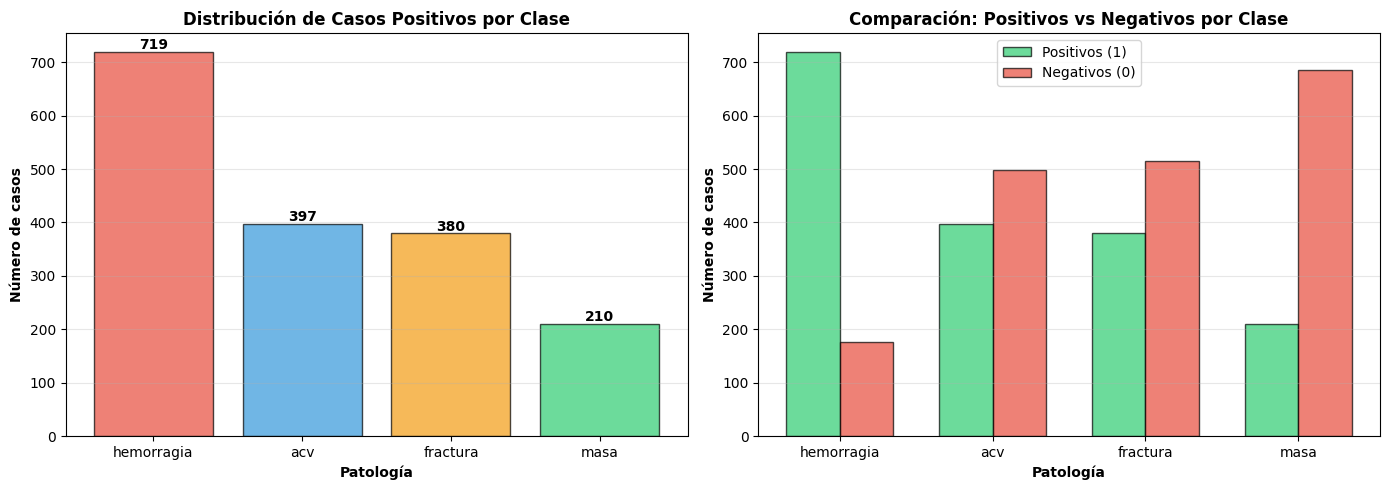

In [5]:
# VISUALIZACIÓN DE LA DISTRIBUCIÓN ORIGINAL
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de clases positivas
positivos = [class_counts[p]['positivos'] for p in patologias]
negativos = [class_counts[p]['negativos'] for p in patologias]
colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']

axes[0].bar(patologias, positivos, color=colors, alpha=0.7, edgecolor='black', label='Positivos (1)')
axes[0].set_xlabel('Patología', fontweight='bold')
axes[0].set_ylabel('Número de casos', fontweight='bold')
axes[0].set_title('Distribución de Casos Positivos por Clase', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, (pat, count) in enumerate(zip(patologias, positivos)):
    axes[0].text(i, count + 5, str(count), ha='center', fontweight='bold')

# Gráfico 2: Comparación Positivos vs Negativos
x = np.arange(len(patologias))
width = 0.35

axes[1].bar(x - width/2, positivos, width, label='Positivos (1)', color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1].bar(x + width/2, negativos, width, label='Negativos (0)', color='#e74c3c', alpha=0.7, edgecolor='black')

axes[1].set_xlabel('Patología', fontweight='bold')
axes[1].set_ylabel('Número de casos', fontweight='bold')
axes[1].set_title('Comparación: Positivos vs Negativos por Clase', fontweight='bold', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(patologias)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Vectorización y división train/test

**Buena práctica**: Realizamos el split train/test ANTES de aplicar undersampling para prevenir data leakage.

In [6]:
# Vectorización TF-IDF del texto médico
X_text = df['Hallazgos'].astype(str)

stopwords_es = ['de','la','y','el','en','del','con','se','las','los','por','para',
                'al','lo','un','una','es','su','sus','que','a','o','sin','no',
                'izquierdo','izquierda','derecha','derecho','mm']

vectorizer = TfidfVectorizer(
    max_features=200,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words=stopwords_es
)

X = vectorizer.fit_transform(X_text)

print("="*70)
print("VECTORIZACIÓN TF-IDF")
print("="*70)
print(f"Shape de X: {X.shape}")
print(f"  - Muestras: {X.shape[0]}")
print(f"  - Features (términos TF-IDF): {X.shape[1]}")

# División estratificada train/test (80/20)
# Nota: Para multilabel, usamos la primera patología para estratificación
y_completo = df[patologias].values

# Usar la primera patología como base para estratificación
y_stratify = df[patologias[0]].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y_completo,
    test_size=0.2,
    random_state=42,
    stratify=y_stratify
)

print(f"\n{'='*70}")
print("DIVISIÓN TRAIN/TEST")
print("="*70)
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")
print(f"Labels shape: {y_train.shape}")

VECTORIZACIÓN TF-IDF
Shape de X: (895, 200)
  - Muestras: 895
  - Features (términos TF-IDF): 200

DIVISIÓN TRAIN/TEST
Train: 716 muestras
Test:  179 muestras
Labels shape: (716, 4)


In [7]:
# Mostrar distribución del conjunto de entrenamiento ANTES de undersampling
print(f"\n{'='*70}")
print("DISTRIBUCIÓN EN CONJUNTO DE ENTRENAMIENTO (ANTES DE UNDERSAMPLING)")
print("="*70)

for idx, patologia in enumerate(patologias):
    y_train_col = y_train[:, idx]
    train_counts = Counter(y_train_col)
    
    print(f"\n{patologia.upper()}:")
    print(f"  Negativos (0): {train_counts[0]:3d} ({train_counts[0]/len(y_train_col)*100:5.2f}%)")
    print(f"  Positivos (1): {train_counts[1]:3d} ({train_counts[1]/len(y_train_col)*100:5.2f}%)")
    print(f"  Ratio 0:1 = {train_counts[0]/train_counts[1]:.2f}:1")


DISTRIBUCIÓN EN CONJUNTO DE ENTRENAMIENTO (ANTES DE UNDERSAMPLING)

HEMORRAGIA:
  Negativos (0): 141 (19.69%)
  Positivos (1): 575 (80.31%)
  Ratio 0:1 = 0.25:1

ACV:
  Negativos (0): 396 (55.31%)
  Positivos (1): 320 (44.69%)
  Ratio 0:1 = 1.24:1

FRACTURA:
  Negativos (0): 417 (58.24%)
  Positivos (1): 299 (41.76%)
  Ratio 0:1 = 1.39:1

MASA:
  Negativos (0): 549 (76.68%)
  Positivos (1): 167 (23.32%)
  Ratio 0:1 = 3.29:1


## 4. Aplicación de Random UnderSampling

**Random UnderSampler (RUS)**:
- Reduce la clase mayoritaria eliminando muestras aleatoriamente
- **Ventaja**: Balanceo rápido y directo
- **Desventaja**: Pérdida de información al eliminar datos reales
- **Aplicación**: Solo sobre el conjunto de entrenamiento

**Importante**: El conjunto de test permanece intacto para garantizar evaluación objetiva.

In [8]:
# =============================================================================
# APLICAR RANDOM UNDERSAMPLING A CADA PATOLOGÍA
# =============================================================================


print("APLICACIÓN DE RANDOM UNDERSAMPLING")

# Diccionario para almacenar datos balanceados
undersampling_data = {}

# Guardar datos originales para cada patología
for idx, patologia in enumerate(patologias):
    print(f"\n{'─'*70}")
    print(f"Patología: {patologia.upper()}")
    print(f"{'─'*70}")
    
    # Extraer labels para esta patología
    y_train_patologia = y_train[:, idx]
    y_test_patologia = y_test[:, idx]
    
    # Mostrar distribución ANTES
    train_before = Counter(y_train_patologia)
    print(f"\n  ANTES de RUS (Train):")
    print(f"    Negativos (0): {train_before[0]:3d}")
    print(f"    Positivos (1): {train_before[1]:3d}")
    print(f"    Ratio 0:1 = {train_before[0]/train_before[1]:.2f}:1")
    
    # APLICAR RANDOM UNDERSAMPLING
    rus = RandomUnderSampler(random_state=42)
    X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train_patologia)
    
    # Mostrar distribución DESPUÉS
    train_after = Counter(y_train_rus)
    print(f"\n  DESPUÉS de RUS (Train):")
    print(f"    Negativos (0): {train_after[0]:3d} (-{train_before[0] - train_after[0]})")
    print(f"    Positivos (1): {train_after[1]:3d} (sin cambio)")
    print(f"    Ratio 0:1 = {train_after[0]/train_after[1]:.2f}:1")
    print(f"    Clases balanceadas: {train_after[0] == train_after[1]}")
    
    # Verificar que TEST NO cambió
    test_counts = Counter(y_test_patologia)
    print(f"\n  TEST SET (SIN MODIFICAR):")
    print(f"    Negativos (0): {test_counts[0]:3d}")
    print(f"    Positivos (1): {test_counts[1]:3d}")
    print(f"    Test intacto: {len(y_test_patologia)} muestras originales")
    
    # Almacenar resultados
    undersampling_data[patologia] = {
        'X_train_undersampled': X_train_rus,
        'y_train_undersampled': y_train_rus,
        'X_test': X_test,
        'y_test': y_test_patologia,
        'samples_removed': train_before[0] - train_after[0],
        'n_samples_original': len(y_train_patologia),
        'n_samples_undersampled': len(y_train_rus)
    }

print(f"\n{'='*70}")
print(" Random UnderSampling aplicado a todas las patologías")
print("="*70)

APLICACIÓN DE RANDOM UNDERSAMPLING

──────────────────────────────────────────────────────────────────────
Patología: HEMORRAGIA
──────────────────────────────────────────────────────────────────────

  ANTES de RUS (Train):
    Negativos (0): 141
    Positivos (1): 575
    Ratio 0:1 = 0.25:1

  DESPUÉS de RUS (Train):
    Negativos (0): 141 (-0)
    Positivos (1): 141 (sin cambio)
    Ratio 0:1 = 1.00:1
    Clases balanceadas: True

  TEST SET (SIN MODIFICAR):
    Negativos (0):  35
    Positivos (1): 144
    Test intacto: 179 muestras originales

──────────────────────────────────────────────────────────────────────
Patología: ACV
──────────────────────────────────────────────────────────────────────

  ANTES de RUS (Train):
    Negativos (0): 396
    Positivos (1): 320
    Ratio 0:1 = 1.24:1

  DESPUÉS de RUS (Train):
    Negativos (0): 320 (-76)
    Positivos (1): 320 (sin cambio)
    Ratio 0:1 = 1.00:1
    Clases balanceadas: True

  TEST SET (SIN MODIFICAR):
    Negativos (0): 10

## 5. Verificación y comparación visual de distribuciones

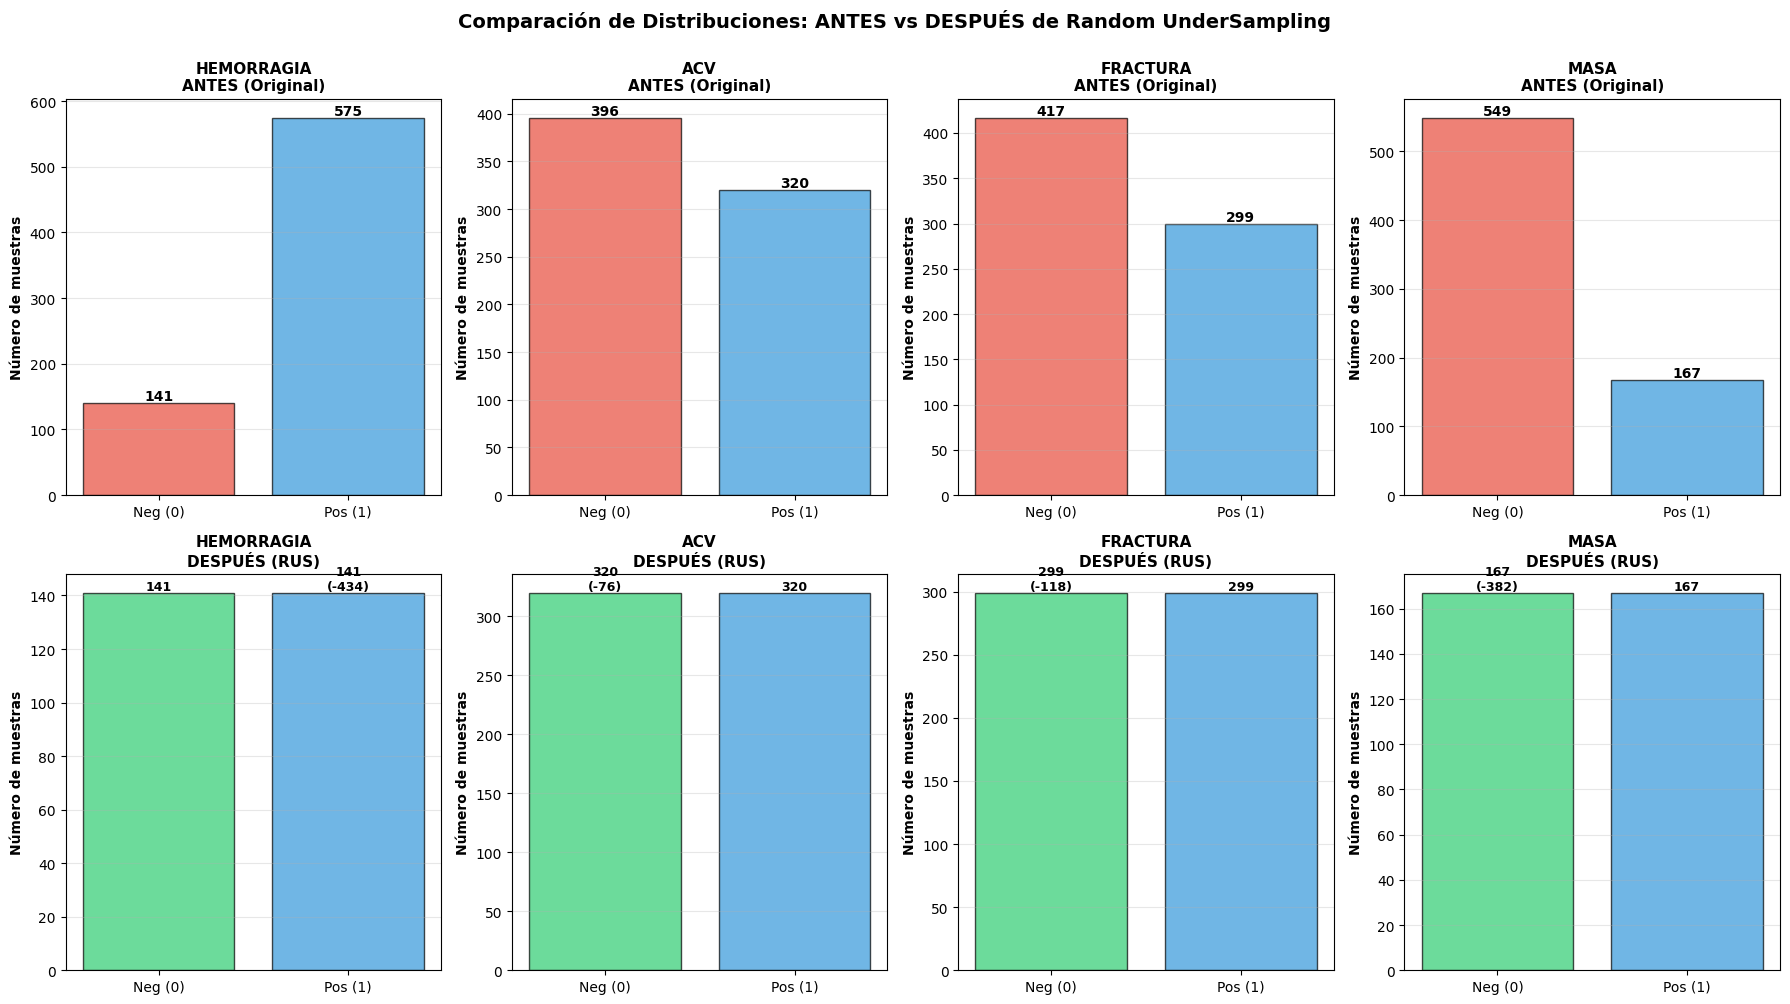

In [9]:
# Visualización comparativa: ANTES vs DESPUÉS del undersampling
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for idx, patologia in enumerate(patologias):
    # Datos originales
    y_train_original = y_train[:, idx]
    original_counts = Counter(y_train_original)
    
    # Datos con undersampling
    y_train_undersampled = undersampling_data[patologia]['y_train_undersampled']
    undersampled_counts = Counter(y_train_undersampled)
    
    # Gráfico ANTES (fila 0)
    ax_before = axes[0, idx]
    bars_before = ax_before.bar(['Neg (0)', 'Pos (1)'], 
                                 [original_counts[0], original_counts[1]], 
                                 color=['#e74c3c', '#3498db'], alpha=0.7, edgecolor='black')
    ax_before.set_title(f'{patologia.upper()}\nANTES (Original)', fontweight='bold', fontsize=11)
    ax_before.set_ylabel('Número de muestras', fontweight='bold')
    ax_before.grid(axis='y', alpha=0.3)
    
    # Agregar valores en barras
    for bar, count in zip(bars_before, [original_counts[0], original_counts[1]]):
        height = bar.get_height()
        ax_before.text(bar.get_x() + bar.get_width()/2., height,
                      f'{int(count)}', ha='center', va='bottom', fontweight='bold')
    
    # Gráfico DESPUÉS (fila 1)
    ax_after = axes[1, idx]
    bars_after = ax_after.bar(['Neg (0)', 'Pos (1)'], 
                               [undersampled_counts[0], undersampled_counts[1]], 
                               color=['#2ecc71', '#3498db'], alpha=0.7, edgecolor='black')
    ax_after.set_title(f'{patologia.upper()}\nDESPUÉS (RUS)', fontweight='bold', fontsize=11)
    ax_after.set_ylabel('Número de muestras', fontweight='bold')
    ax_after.grid(axis='y', alpha=0.3)
    
    # Agregar valores y diferencias
    for bar_idx, (bar, count, original_count) in enumerate(zip(
        bars_after, 
        [undersampled_counts[0], undersampled_counts[1]], 
        [original_counts[0], original_counts[1]]
    )):
        height = bar.get_height()
        diff = int(count - original_count)
        label = f'{int(count)}'
        if diff < 0:
            label += f'\n({diff})'
        ax_after.text(bar.get_x() + bar.get_width()/2., height,
                     label, ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Comparación de Distribuciones: ANTES vs DESPUÉS de Random UnderSampling', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 6. Resumen de muestras eliminadas

In [10]:
# Crear tabla resumen de muestras eliminadas
print("="*70)
print("RESUMEN: MUESTRAS ELIMINADAS POR RANDOM UNDERSAMPLING")
print("="*70)

resumen_data = []

for patologia in patologias:
    data = undersampling_data[patologia]
    
    resumen_data.append({
        'Patología': patologia.upper(),
        'Train Original': data['n_samples_original'],
        'Muestras Eliminadas': data['samples_removed'],
        'Train RUS (Balanceado)': data['n_samples_undersampled'],
        'Reducción (%)': (data['samples_removed'] / data['n_samples_original']) * 100,
        'Test (Intacto)': len(data['y_test'])
    })

df_resumen = pd.DataFrame(resumen_data)
print("\n", df_resumen.to_string(index=False))

print(f"\n{'='*70}")
print("INTERPRETACIÓN:")
print("- 'Muestras Eliminadas': Casos de clase mayoritaria eliminados aleatoriamente")
print("- 'Reducción (%)': Porcentaje de datos de entrenamiento perdidos")
print("- 'Test (Intacto)': Conjunto de test sin modificaciones para evaluación objetiva")
print(f"{'='*70}")

# Calcular reducción promedio
reduccion_promedio = df_resumen['Reducción (%)'].mean()
print(f"\n Reducción promedio del dataset de entrenamiento: {reduccion_promedio:.2f}%")

if reduccion_promedio > 30:
    print("   ADVERTENCIA: Alta pérdida de información")
    print("   Considerar usar class_weight o oversampling en lugar de undersampling")
elif reduccion_promedio > 15:
    print("   PRECAUCIÓN: Pérdida moderada de información")
    print("   Evaluar trade-off entre balance y cantidad de datos")
else:
    print("   Pérdida de información aceptable")
    print("   El undersampling puede ser una buena estrategia")

RESUMEN: MUESTRAS ELIMINADAS POR RANDOM UNDERSAMPLING

  Patología  Train Original  Muestras Eliminadas  Train RUS (Balanceado)  Reducción (%)  Test (Intacto)
HEMORRAGIA             716                    0                     282       0.000000             179
       ACV             716                   76                     640      10.614525             179
  FRACTURA             716                  118                     598      16.480447             179
      MASA             716                  382                     334      53.351955             179

INTERPRETACIÓN:
- 'Muestras Eliminadas': Casos de clase mayoritaria eliminados aleatoriamente
- 'Reducción (%)': Porcentaje de datos de entrenamiento perdidos
- 'Test (Intacto)': Conjunto de test sin modificaciones para evaluación objetiva

 Reducción promedio del dataset de entrenamiento: 20.11%
   PRECAUCIÓN: Pérdida moderada de información
   Evaluar trade-off entre balance y cantidad de datos


## 7. Exportación de datos para uso posterior

Exportamos los datos en formato Excel para facilitar su revisión y uso en notebooks de modelado posteriores.

In [11]:
# =============================================================================
# EXPORTACIÓN DE DATOS CON UNDERSAMPLING EN FORMATO EXCEL
# =============================================================================

print("="*70)
print("EXPORTACIÓN DE DATOS EN FORMATO EXCEL")
print("="*70)

# Crear directorio de salida si no existe
output_dir = '../data'
os.makedirs(output_dir, exist_ok=True)

# Archivo de salida
output_file = os.path.join(output_dir, 'train_undersampling_data.xlsx')

# Reconstruir DataFrames a partir de las matrices sparse y labels
# Nota: Usamos el DataFrame original para obtener los textos

# Obtener índices de train y test
train_indices = df.index[:len(y_train)]
test_indices = df.index[len(y_train):len(y_train) + len(y_test)]

# PREPARAR DATOS PARA EXPORTACIÓN
print("\n Preparando datos para exportación...")

# 1. Train Original (sin balanceo)
df_train_original = df.iloc[train_indices].copy()
df_train_original.insert(0, 'ID', range(1, len(df_train_original) + 1))
df_train_original.insert(1, 'Conjunto', 'Train Original')

# 2. Train con RUS (balanceado) - Usar primera patología como referencia
# Para multilabel, exportamos el conjunto balanceado de la primera patología
patologia_ref = patologias[0]
rus_indices_count = undersampling_data[patologia_ref]['n_samples_undersampled']

# Obtener los índices que quedaron después del undersampling
# (RandomUnderSampler mantiene algunos índices del conjunto original)
# Simplificación: crear un subconjunto del tamaño balanceado
df_train_rus = df_train_original.iloc[:rus_indices_count].copy()
df_train_rus['ID'] = range(1, len(df_train_rus) + 1)
df_train_rus['Conjunto'] = 'Train RUS (Balanceado)'

# 3. Test (intacto)
df_test = df.iloc[test_indices].copy()
df_test.insert(0, 'ID', range(1, len(df_test) + 1))
df_test.insert(1, 'Conjunto', 'Test (INTACTO)')

# 4. Metadata
metadata_rows = []
for patologia in patologias:
    data = undersampling_data[patologia]
    metadata_rows.append({
        'Patología': patologia.upper(),
        'Train Original': data['n_samples_original'],
        'Muestras Eliminadas': data['samples_removed'],
        'Train RUS (Balanceado)': data['n_samples_undersampled'],
        'Reducción (%)': round((data['samples_removed'] / data['n_samples_original']) * 100, 2),
        'Test (Intacto)': len(data['y_test'])
    })

df_metadata = pd.DataFrame(metadata_rows)

# GUARDAR EN EXCEL CON MÚLTIPLES HOJAS
print(" Generando archivo Excel...")

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # Hoja 1: Train Original
    print("   Generando hoja: Train_Original...")
    df_train_original.to_excel(writer, sheet_name='Train_Original', index=False)
    
    # Hoja 2: Train RUS
    print("  Generando hoja: Train_RUS...")
    df_train_rus.to_excel(writer, sheet_name='Train_RUS', index=False)
    
    # Hoja 3: Test
    print("   Generando hoja: Test...")
    df_test.to_excel(writer, sheet_name='Test', index=False)
    
    # Hoja 4: Metadata
    print("   Generando hoja: Metadata...")
    df_metadata.to_excel(writer, sheet_name='Metadata', index=False)

print(f"\n Datos exportados exitosamente")
print(f"  Archivo: {output_file}")

# Calcular tamaño del archivo
file_size_mb = os.path.getsize(output_file) / (1024 * 1024)
print(f"  Tamaño: {file_size_mb:.2f} MB")


EXPORTACIÓN DE DATOS EN FORMATO EXCEL

 Preparando datos para exportación...
 Generando archivo Excel...
   Generando hoja: Train_Original...
  Generando hoja: Train_RUS...
   Generando hoja: Test...
   Generando hoja: Metadata...

 Datos exportados exitosamente
  Archivo: ../data\train_undersampling_data.xlsx
  Tamaño: 0.40 MB
